In [24]:
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [25]:
def relu(x):
    """ReLU activation function: max(0, x)"""
    assert isinstance(x, np.ndarray), "Input to ReLU must be a numpy array"
    result = np.maximum(0, x)
    assert np.all(result >= 0), "ReLU output must be non-negative"
    return result

In [26]:
def relu_derivative(x):
    """Derivative of ReLU function: 1 if x > 0 else 0"""
    assert isinstance(x, np.ndarray), "Input to ReLU derivative must be a numpy array"
    result = (x > 0).astype(float)
    assert np.all((result == 0) | (result == 1)), "ReLU derivative must be 0 or 1"
    return result

In [27]:
def softmax(x):
    """Numerically stable Softmax activation function"""
    assert isinstance(x, np.ndarray), "Input to softmax must be a numpy array"
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    result = exp_x / np.sum(exp_x, axis=1, keepdims=True)
    assert np.all((result >= 0) & (result <= 1)), "Softmax output must be in [0, 1]"
    assert np.allclose(np.sum(result, axis=1), 1), "Softmax output must sum to 1 per sample"
    return result

In [28]:
class MultiClassNeuralNetwork:
    def __init__(self, layer_sizes, learning_rate=0.01, l2_lambda=0.01):
        assert isinstance(layer_sizes, list) and len(layer_sizes) >= 2, "layer_sizes must be a list with at least 2 elements"
        assert all(isinstance(size, int) and size > 0 for size in layer_sizes), "All layer sizes must be positive integers"
        assert isinstance(learning_rate, (int, float)) and learning_rate > 0, "Learning rate must be a positive number"

        self.layer_sizes = layer_sizes
        self.learning_rate = learning_rate
        self.l2_lambda = l2_lambda
        self.weights = []
        self.biases = []

        np.random.seed(42)
        for i in range(len(layer_sizes) - 1):
            w = np.random.randn(layer_sizes[i], layer_sizes[i + 1]) * 0.01
            b = np.zeros((1, layer_sizes[i + 1]))
            assert w.shape == (layer_sizes[i], layer_sizes[i + 1]), f"Weight matrix {i + 1} has incorrect shape"
            assert b.shape == (1, layer_sizes[i + 1]), f"Bias vector {i + 1} has incorrect shape"
            self.weights.append(w)
            self.biases.append(b)

    def forward(self, X):
        assert isinstance(X, np.ndarray), "Input X must be a numpy array"
        assert X.shape[1] == self.layer_sizes[0], f"Input dimension ({X.shape[1]}) must match input layer size ({self.layer_sizes[0]})"

        self.activations = [X]
        self.z_values = []

        # Hidden layers (ReLU)
        for i in range(len(self.weights) - 1):
            z = self.activations[-1] @ self.weights[i] + self.biases[i]
            assert z.shape == (X.shape[0], self.layer_sizes[i + 1]), f"Z^{i + 1} has incorrect shape"
            self.z_values.append(z)
            self.activations.append(relu(z))

        # Output layer (Softmax)
        z = self.activations[-1] @ self.weights[-1] + self.biases[-1]
        assert z.shape == (X.shape[0], self.layer_sizes[-1]), "Output Z has incorrect shape"
        self.z_values.append(z)
        
        output = softmax(z)
        assert output.shape == (X.shape[0], self.layer_sizes[-1]), "Output A has incorrect shape"
        self.activations.append(output)

        return self.activations[-1]

    def compute_loss(self, y_true, y_pred):
        assert isinstance(y_true, np.ndarray) and isinstance(y_pred, np.ndarray), "Inputs to loss must be numpy arrays"
        assert y_true.shape == y_pred.shape, "y_true and y_pred must have the same shape"

        m = y_true.shape[0]
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
        loss = -np.sum(y_true * np.log(y_pred)) / m
        assert not np.isnan(loss), "Loss computation resulted in NaN"
        return loss

    def compute_accuracy(self, y_true, y_pred):
        assert isinstance(y_true, np.ndarray) and isinstance(y_pred, np.ndarray), "Inputs to accuracy must be numpy arrays"
        assert y_true.shape == y_pred.shape, "y_true and y_pred must have the same shape"

        predictions = np.argmax(y_pred, axis=1)
        true_labels = np.argmax(y_true, axis=1)
        accuracy = np.mean(predictions == true_labels)
        assert 0 <= accuracy <= 1, "Accuracy must be between 0 and 1"
        return accuracy

    def backward(self, X, y, outputs):
        assert isinstance(X, np.ndarray) and isinstance(y, np.ndarray) and isinstance(outputs, np.ndarray), "Inputs to backward must be numpy arrays"
        assert X.shape[1] == self.layer_sizes[0], f"Input dimension ({X.shape[1]}) must match input layer size ({self.layer_sizes[0]})"
        assert y.shape == outputs.shape, "y and outputs must have the same shape"

        m = X.shape[0]
        self.d_weights = [np.zeros_like(w) for w in self.weights]
        self.d_biases = [np.zeros_like(b) for b in self.biases]

        # Output layer gradient
        dZ = outputs - y
        assert dZ.shape == outputs.shape, "dZ for output layer has incorrect shape"
        
        self.d_weights[-1] = (self.activations[-2].T @ dZ) / m
        self.d_biases[-1] = np.sum(dZ, axis=0, keepdims=True) / m

        # Hidden layers backpropagation
        for i in range(len(self.weights) - 2, -1, -1):
            dZ = (dZ @ self.weights[i + 1].T) * relu_derivative(self.z_values[i])
            assert dZ.shape == (X.shape[0], self.layer_sizes[i + 1]), f"dZ^{i + 1} has incorrect shape"
            
            self.d_weights[i] = (self.activations[i].T @ dZ) / m
            self.d_biases[i] = np.sum(dZ, axis=0, keepdims=True) / m

        # Add L2 Regularization to weight gradients
        for i in range(len(self.weights)):
            self.d_weights[i] += (self.l2_lambda / m) * self.weights[i]

        # SGD Update
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * self.d_weights[i]
            self.biases[i] -= self.learning_rate * self.d_biases[i]

    def train(self, X, y, X_val, y_val, epochs, batch_size):
        assert isinstance(X, np.ndarray) and isinstance(y, np.ndarray), "X and y must be numpy arrays"
        assert isinstance(X_val, np.ndarray) and isinstance(y_val, np.ndarray), "X_val and y_val must be numpy arrays"

        train_losses, val_losses = [], []
        train_accuracies, val_accuracies = [], []

        for epoch in range(epochs):
            indices = np.random.permutation(X.shape[0])
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_loss = 0
            num_batches = 0
            for i in range(0, X.shape[0], batch_size):
                X_batch = X_shuffled[i:i + batch_size]
                y_batch = y_shuffled[i:i + batch_size]

                outputs = self.forward(X_batch)
                epoch_loss += self.compute_loss(y_batch, outputs)
                self.backward(X_batch, y_batch, outputs)
                num_batches += 1

            train_loss = epoch_loss / num_batches
            train_pred = self.forward(X)
            train_accuracy = self.compute_accuracy(y, train_pred)
            val_pred = self.forward(X_val)
            val_loss = self.compute_loss(y_val, val_pred)
            val_accuracy = self.compute_accuracy(y_val, val_pred)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accuracies.append(train_accuracy)
            val_accuracies.append(val_accuracy)

            if epoch % 10 == 0 or epoch == epochs - 1:
                print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                      f"Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

        return train_losses, val_losses, train_accuracies, val_accuracies
    def predict(self, X):
        assert isinstance(X, np.ndarray), "Input X must be a numpy array"
        assert X.shape[1] == self.layer_sizes[0], f"Input dimension ({X.shape[1]}) must match input layer size ({self.layer_sizes[0]})"

        outputs = self.forward(X)
        predictions = np.argmax(outputs, axis=1)
        assert predictions.shape == (X.shape[0],), "Predictions have incorrect shape"
        return predictions

In [29]:
dataset_dir = r"C:\Users\moham\OneDrive\Desktop\tp DL\AMHCD_64"

image_paths = []
labels = []

# Parcours des dossiers de classes
for label_dir in os.listdir(dataset_dir):
    full_label_dir = os.path.join(dataset_dir, label_dir)
    if os.path.isdir(full_label_dir):
        for img_name in os.listdir(full_label_dir):
            image_paths.append(os.path.join(full_label_dir, img_name))
            labels.append(label_dir)

labels_df = pd.DataFrame({'image_path': image_paths, 'label': labels})

# Vérification
assert not labels_df.empty, "No data loaded. Check dataset directory."

label_encoder = LabelEncoder()
labels_df['label_encoded'] = label_encoder.fit_transform(labels_df['label'])

In [30]:
def load_and_preprocess_image(image_path, target_size=(32, 32)):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    assert img is not None, f"Failed to load image: {image_path}"
    img = cv2.resize(img, target_size)
    return (img.astype(np.float32) / 255.0).flatten()

X = np.array([load_and_preprocess_image(path) for path in labels_df['image_path']])
y = labels_df['label_encoded'].values

# %% [5] Train-Validation-Test Data Split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

X_train, X_val, X_test = np.array(X_train), np.array(X_val), np.array(X_test)
y_train, y_val, y_test = np.array(y_train), np.array(y_val), np.array(y_test)

one_hot_encoder = OneHotEncoder(sparse_output=False)
y_train_one_hot = np.array(one_hot_encoder.fit_transform(y_train.reshape(-1, 1)))
y_val_one_hot = np.array(one_hot_encoder.transform(y_val.reshape(-1, 1)))
y_test_one_hot = np.array(one_hot_encoder.transform(y_test.reshape(-1, 1)))

print(f"Data partitioning successfully complete:")
print(f"Train: {X_train.shape[0]} samples | Validation: {X_val.shape[0]} samples | Test: {X_test.shape[0]} samples")

Data partitioning successfully complete:
Train: 15444 samples | Validation: 5148 samples | Test: 5148 samples


In [31]:
num_classes = len(label_encoder.classes_)
print(f"Number of classes : {num_classes}")
layer_sizes = [X_train.shape[1], 128, 64, num_classes]
nn = MultiClassNeuralNetwork(layer_sizes, learning_rate=0.01, l2_lambda=0.01)

train_losses, val_losses, train_accuracies, val_accuracies = nn.train(
    X_train, y_train_one_hot, X_val, y_val_one_hot, epochs=100, batch_size=32
)

# %% [7] Model Evaluation (Classification Report)
y_pred = nn.predict(X_test)
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Number of classes : 33
Epoch 000 | Train Loss: 3.4967 | Val Loss: 3.4965 | Train Acc: 0.0287 | Val Acc: 0.0291
Epoch 010 | Train Loss: 3.4959 | Val Loss: 3.4957 | Train Acc: 0.0681 | Val Acc: 0.0668
Epoch 020 | Train Loss: 3.1372 | Val Loss: 3.0357 | Train Acc: 0.0772 | Val Acc: 0.0773
Epoch 030 | Train Loss: 2.3022 | Val Loss: 2.6782 | Train Acc: 0.1442 | Val Acc: 0.1496
Epoch 040 | Train Loss: 1.3519 | Val Loss: 1.1645 | Train Acc: 0.6533 | Val Acc: 0.6476
Epoch 050 | Train Loss: 0.9173 | Val Loss: 1.3249 | Train Acc: 0.5804 | Val Acc: 0.5765
Epoch 060 | Train Loss: 0.6376 | Val Loss: 0.9654 | Train Acc: 0.7058 | Val Acc: 0.6983
Epoch 070 | Train Loss: 0.5356 | Val Loss: 0.9243 | Train Acc: 0.7214 | Val Acc: 0.7162
Epoch 080 | Train Loss: 0.4525 | Val Loss: 0.5057 | Train Acc: 0.8739 | Val Acc: 0.8596
Epoch 090 | Train Loss: 0.3923 | Val Loss: 0.6615 | Train Acc: 0.8239 | Val Acc: 0.8104
Epoch 099 | Train Loss: 0.3608 | Val Loss: 0.3967 | Train Acc: 0.9110 | Val Acc: 0.8881

Classifi

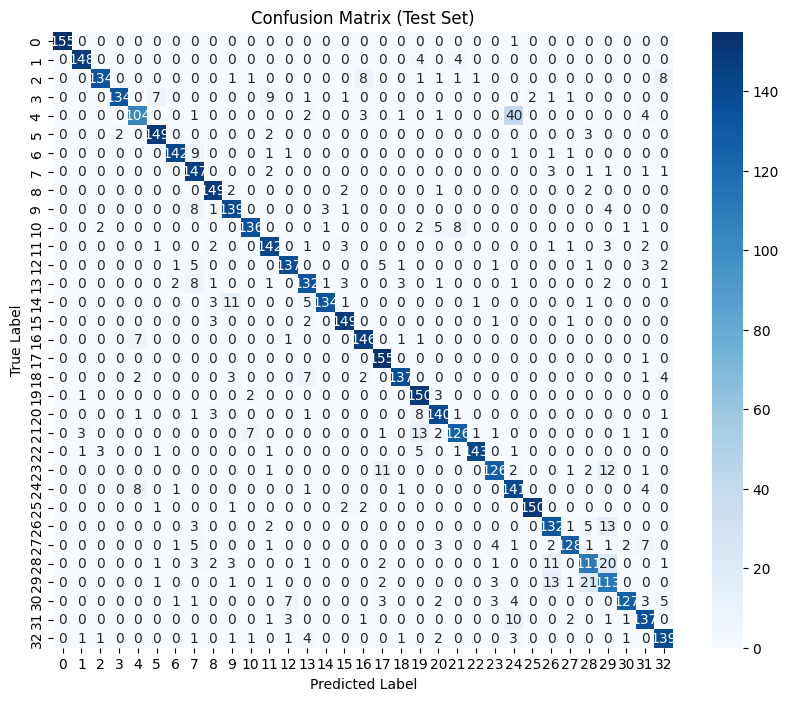

In [32]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

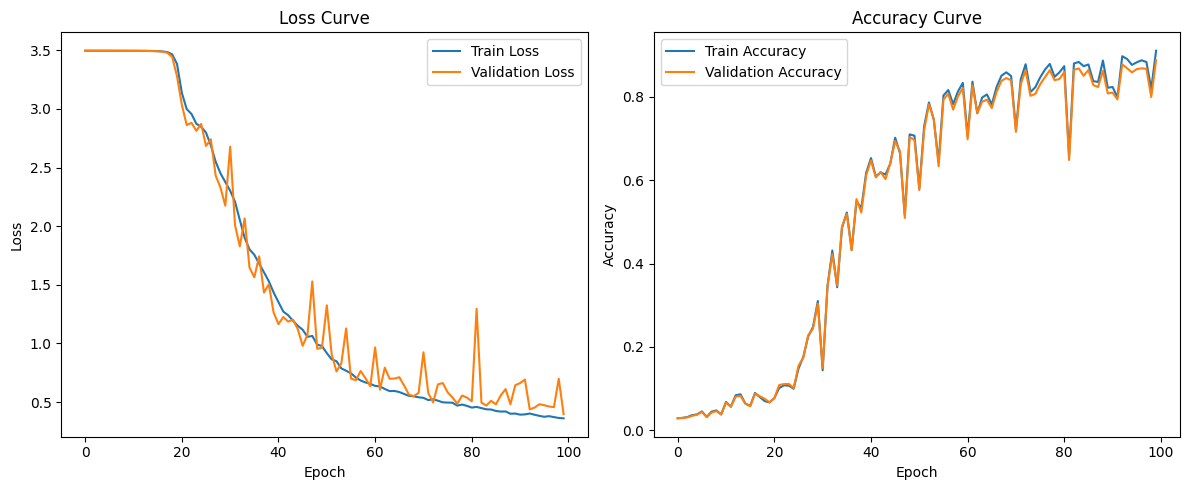

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Validation Loss')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(train_accuracies, label='Train Accuracy')
ax2.plot(val_accuracies, label='Validation Accuracy')
ax2.set_title('Accuracy Curve')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()